In [2]:
%pip install pandas scikit-learn matplotlib numpy

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 25.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 25.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 24.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 42.0 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 35.1 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 40.4 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

Pipeline Score (RBF Kernel): 0.8333333333333334


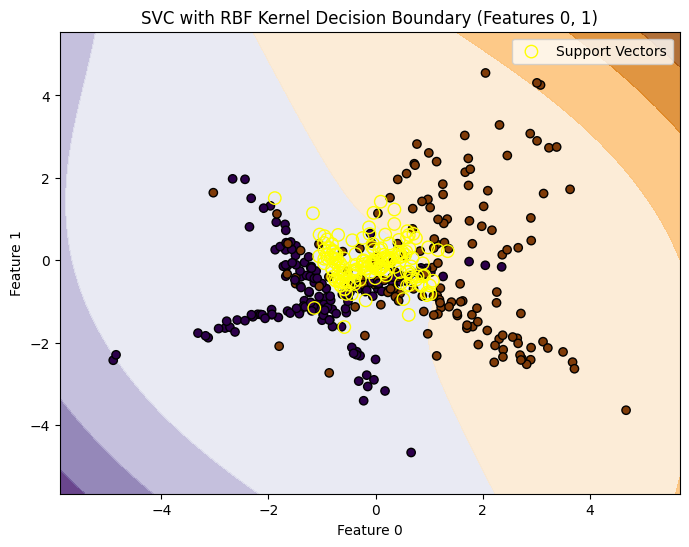

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay

# Assuming 'preprocessing.py' and 'load_modeling_data' are correctly implemented
# from preprocessing import load_modeling_data
# X, y = load_modeling_data()

# Create dummy data for demonstration if load_modeling_data is unavailable
# Replace this if you have the actual function
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=300, n_features=4, n_informative=3, n_redundant=1, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 1. Train with a nonlinear kernel (RBF) ---
# Change kernel="linear" to kernel="rbf"
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", random_state=42)) # RBF kernel, you can also use 'poly'
])
pipeline.fit(X_train, y_train)

print("Pipeline Score (RBF Kernel):", pipeline.score(X_test, y_test))

# --- 2. Plot the results (for 2 features) ---

def plot_decision_boundary(pipeline, X, y, feature_indices=(0, 1)):
    """
    Plots the decision boundary of the SVC pipeline using only two features.
    
    Args:
        pipeline: The trained sklearn pipeline.
        X: The full feature set (numpy array or pandas DataFrame).
        y: The target labels.
        feature_indices: A tuple of two indices for the features to plot.
    """
    # Select the two features for plotting
    X_plot = X[:, feature_indices] if isinstance(X, np.ndarray) else X.iloc[:, feature_indices]
    
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    
    # Plot the decision boundary
    # We create a temporary pipeline with only the selected features for the plot utility
    temp_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", random_state=42))
    ])
    temp_pipeline.fit(X_plot, y)
    
    DecisionBoundaryDisplay.from_estimator(
        temp_pipeline, 
        X_plot, 
        cmap=plt.cm.PuOr_r, 
        alpha=0.8, 
        ax=ax, 
        response_method="decision_function" # Plots the margins as well
    )

    # Plot the training points
    scatter = ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y, cmap=plt.cm.PuOr_r, edgecolors='k')
    
    # Plot support vectors
    # Note: Accessing support vectors directly requires fitting a temporary model as pipeline doesn't expose them easily
    ax.scatter(temp_pipeline["svm"].support_vectors_[:, 0], 
               temp_pipeline["svm"].support_vectors_[:, 1], 
               s=80, 
               facecolors='none', 
               edgecolors='yellow', 
               label='Support Vectors')

    ax.set_title("SVC with RBF Kernel Decision Boundary (Features {}, {})".format(feature_indices[0], feature_indices[1]))
    ax.set_xlabel(f"Feature {feature_indices[0]}")
    ax.set_ylabel(f"Feature {feature_indices[1]}")
    ax.legend()
    plt.show()

# Example of plotting the decision boundary using the first two features (indices 0 and 1)
if X.shape[1] >= 2:
    plot_decision_boundary(pipeline, X, y, feature_indices=(0, 1))
else:
    print("Cannot plot decision boundary with less than 2 features.")
